# Networkx

* Пакет для Python для манипулирования графиками и их анализа
* Содержит множество стандатных алгоритмов для графов

In [1]:
import networkx          as nx
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

## Создание графов

Networkx поддерживает неориентированные/ориентированные графы/мультиграфы (мультиграфы позволяют одной паре узлов иметь несколько ребер):
*  Неориентированный граф: `nx.Graph`
*  Ориентированный граф: `nx.DiGraph`
*  Неориентированный мультиграф: `nx.MultiGraph`
*  Ориентированный мультиграф: `nx.MultiDiGraph`

In [3]:
G = nx.Graph()
G

Networkx имеет отличный набор методов для отображения графов. Напишем функцию, которую будем использовать на вывода графов на экран

In [92]:
def plot_graph(G, node_weights=None, figsize=(6, 5)):

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    options = dict(
        ax         = ax,       # ось
        font_size  = 12,       # размер шрифта подписей
        node_size  = 500,      # размер вершин
        edgecolors = "black",  # цвет обводки вершин
    )
    
    # Если переданы веса вершин – раскрашиваем ...
    if node_weights is not None:

        # Собрать массив весов из вершин графа (если веса нет: 0)
        weights = np.array([node_weights.get(node, 0) for node in G.nodes()])

        # Объект нормализации: [min_w; max_w] -> [0; 1]
        norm = plt.Normalize(vmin=weights.min(), vmax=weights.max())

        # Стандартная цветовая карта
        cmap = plt.cm.Oranges

        # Границы цветовой карты
        minval = 0.2
        maxval = 1.0
        # Дискретные шаги
        n = 100

        # Формируем усеченную цветовую карту
        truncated_cmap = colors.LinearSegmentedColormap.from_list(
            # "trunc(orange,0.20,1.00)"
            name = "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
            # [0.2, 0.208, 0.216, ..., 1.0]
            colors = cmap(np.linspace(minval, maxval, n))
        )

        # w in weights -> norm(w) -> truncated_cmap -> options["node_color"]
        options["node_color"] = [truncated_cmap(norm(w)) for w in weights]

    else:
        # Если весов нет — все вершины белые
        options["node_color"] = "white"
    

    # Координаты вершин (модель пружин, вершины отталкиваются)
    pos = nx.spring_layout(G)

    # Нарисовать граф
    nx.draw_networkx(G, pos, **options)

    # Если есть веса на рёбрах
    if nx.is_weighted(G):
        # Cловарь {ребро: вес} для вывода
        labels = {e: G.edges[e]["weight"] for e in G.edges}
        # Наримовать подписи рёбер с их весами
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        
    # Если есть веса — добавить colorbar
    if node_weights is not None:
        # Map one or multiple sets of scalar data to RGBA.
        sm = plt.cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax)

Классы графов имеют интерфейс для явного добавления ребер и узлов:

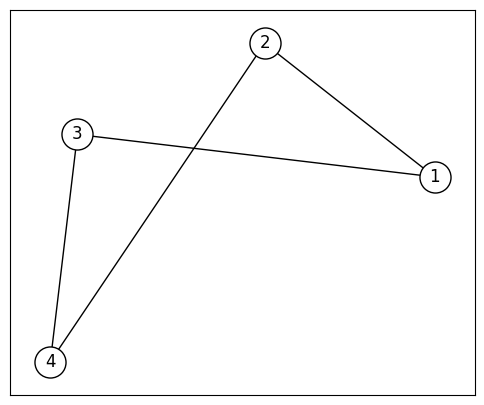

In [71]:
G = nx.Graph()

# Ребро между вершинами 1 и 2 (вершины создадутся автоматически)
G.add_edge(1, 2)

G.add_edge(2, 4)
G.add_edge(1, 3)
G.add_edge(3, 4)

plot_graph(G)

Направленный граф создается с помощью класса `nx.DiGraph`:

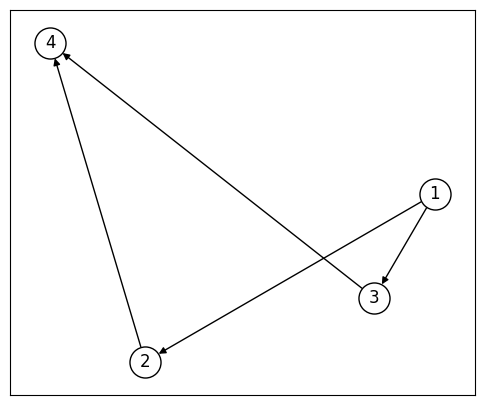

In [60]:
G = nx.DiGraph()

G.add_edge(1, 2)
G.add_edge(2, 4)

G.add_edge(1, 3)
G.add_edge(3, 4)

plot_graph(G)

Мы также можем создать граф напрямую из списка ребер:

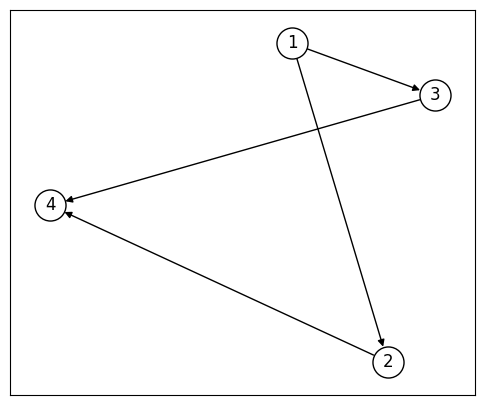

In [67]:
G = nx.DiGraph()
edges = [(1, 2), (2, 4), (1, 3), (3, 4)]
G.add_edges_from(edges)
plot_graph(G)

Опционально мы всегда можем сделать граф взвешенным. Для этого в метод `add_edge()` передается ключевое слово `weight`. Тоже можно сделать и используя метод `add_weighted_edges_from()`:

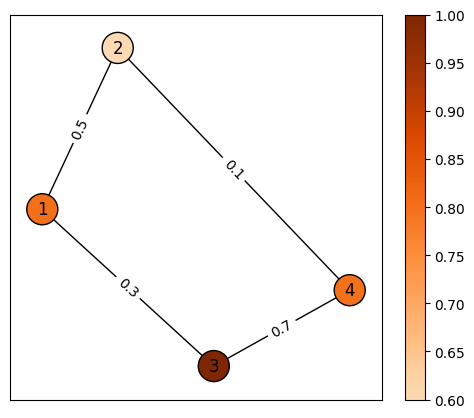

In [94]:
G = nx.Graph()

# (вершина_1, вершина_2, вес)
edges = [(1, 2, 0.5), (2, 4, 0.1), (1, 3, 0.3), (3, 4, 0.7)]
G.add_weighted_edges_from(edges)

node_weights = {n: sum( d["weight"] for _, _, d in G.edges(n, data=True) )
                for n in G.nodes()}

plot_graph(G, node_weights=node_weights)

Названия узлов могут быть произвольными hashable.  
Мы также может добавлять произвольные аттрибуты к узлам и ребрам:

In [98]:
# Граф городов (ориентированный/неориентированный)
def create_city_graph(directed=True):

    G = nx.DiGraph() if directed else nx.Graph()

    # добавить множество вершин
    G.add_nodes_from([
        #                    словарь внутри кортежа
        ("Moscow",           dict(population=13.1)),
        ("Saint Petersburg", dict(population=5.6)),
        ("Kazan",            dict(population=1.3)),
        ("Novosibirsk",      dict(population=1.6)),
    ])

    #                                        аргумент внутри функции (одиночный вызов)
    G.add_edge("Moscow", "Saint Petersburg", distance=712)
    G.add_edge("Moscow", "Kazan",            distance=816)
    G.add_edge("Moscow", "Novosibirsk",      distance=3356)

    return G

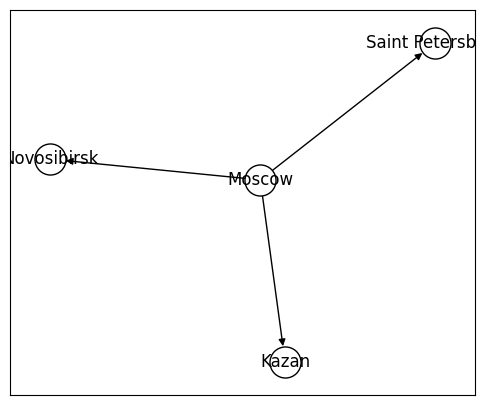

In [111]:
G = create_city_graph()
plot_graph(G)

## Доступ к узлам и ребрам

Networkx предоставляет удобный интерфейс для доступа к узлам/ребрам и их аттрибутам, а также позволяет легко итерироваться по ним.  
Рассмотрим несколько популярных операций

In [113]:
# Количество узлов в графе
len(G)

4

In [114]:
# Количество ребер в графе
len(G.edges)

3

In [116]:
# Присутствует ли узел в графе
"Moscow" in G
G.has_node("Moscow")

True

In [119]:
# Присутствует ли ребро в графе
("Moscow", "Saint Petersburg") in G.edges
G.has_edge("Moscow", "Saint Petersburg")

True

In [120]:
# Итерация по узлам
for n in G:
    if n != "Moscow":
        print(n)

Saint Petersburg
Kazan
Novosibirsk


In [121]:
# Итерация по ребрам
for e in G.edges:
    print(e)

('Moscow', 'Saint Petersburg')
('Moscow', 'Kazan')
('Moscow', 'Novosibirsk')


In [122]:
# Итерация по ребрам вместе с атрибутами
for n_in, n_out, dist in G.edges.data("distance"):
    print(f"{n_in} -- {n_out} ({dist} km)")

Moscow -- Saint Petersburg (712 km)
Moscow -- Kazan (816 km)
Moscow -- Novosibirsk (3356 km)


## Доступ к соседям

Для начала рассмотрим случай ненаправленного графа.

Множество соседей данного узла можно получить, используя `G.neighbors(n)` или `G.adj[n]`. Например, итерация по соседям узла может выглядеть так:

In [ ]:
for n in G.neighbors("Moscow"):
    print(n)

Saint Petersburg
Kazan
Novosibirsk


Или так:

In [124]:
# Словарь смежности
for n in G.adj["Moscow"]:
    print(n)

Saint Petersburg
Kazan
Novosibirsk


В направленных графах при рассмотрении соседей данного узла, то есть смежных узлов, нам важно разделять in-edges и out-edges. Для получения доступа к in-edges используется метод `G.predecessors()`, а для out-edges метод `G.successors()`.

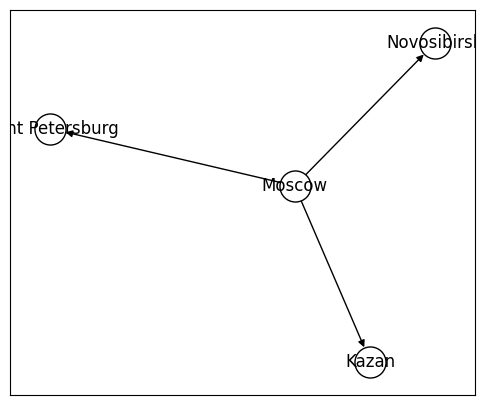

In [ ]:
G = create_city_graph(directed=True)
plot_graph(G)

In [126]:
for n in G.successors("Moscow"):
    print(n)

Saint Petersburg
Kazan
Novosibirsk


In [127]:
for n in G.predecessors("Saint Petersburg"):
    print(n)

Moscow


Для нахождения степени вершины используется метод `G.degree(n)`, который реализован и для ненаправленных и для направленных графов. Для направленных графов существуют также отдельные методы для полустепеней захода и исхода (indegree и outdegree), `G.in_degree(n)` и `G.out_degree(n)` соответственно.

In [ ]:
# in + out
G.degree("Moscow")

3

In [131]:
G.in_degree("Saint Petersburg")

1

In [132]:
G.out_degree("Saint Petersburg")

0

### Упражнение 1

Напишите функцию, вычисляющую среднюю степень соседей для каждого из узлов, у которых в принципе есть соседи

In [145]:
from typing import Any

def avg_neighb_degree(g: nx.Graph) -> dict[Any, float]:
    data = {}
    for n in g.nodes():
        if g.is_directed():
            neighbors = set(g.successors(n)) | set(g.predecessors(n))
        else:
            neighbors = set(g.neighbors(n))
        if neighbors:
            data[n] = np.mean([g.degree(i) for i in neighbors])
    return data

In [146]:
avg_neighb_degree(G)

{'Moscow': np.float64(1.0),
 'Saint Petersburg': np.float64(3.0),
 'Kazan': np.float64(3.0),
 'Novosibirsk': np.float64(3.0)}

{0: np.float64(3.0), 1: np.float64(3.0), 2: np.float64(2.0), 3: np.float64(3.0), 4: np.float64(3.0)}


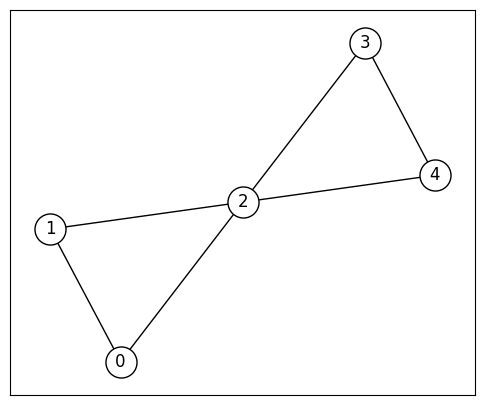

In [ ]:
# Эрдеш–Реньи: 10 вершин, вероятность ребра 0.2, неориентированный
ER = nx.erdos_renyi_graph(n=5, p=0.5, directed=False)
print(avg_neighb_degree(ER))
plot_graph(ER)

## Загрузка и сохранение графов

Наконец, мы можем сохранять графы в файлы и вычитывать их из них. Для простых задач мы можем использовать `adjlist` и `edgelist` форматы:
* `adjlist` является компактным представлением матрицы смежности. Он не подходит для графов с аттрибутами
* `edgelist` является списком ребер с их аттрибутами
* Для обоих методов названия узлов не должны включать пробелов

In [154]:
G = nx.Graph()
edges = [(1, 2, 0.5), (1, 3, 0.3), (2, 4, 0.1), (3, 4, 0.7)]
G.add_weighted_edges_from(edges)

In [155]:
# Матрица смежности без атрибутов
nx.write_adjlist(G, "g.adjlist")

In [156]:
# Список ребер с атрибутами
nx.write_edgelist(G, "g.edgelist")

Методы `nx.read_adjlist()` и `nx.read_edgelist()` используются для чтения графов из файлов соответствующих форматов:

In [158]:
G_1 = nx.read_adjlist("g.adjlist")
G_1

In [159]:
G_2 = nx.read_edgelist("g.edgelist")
G_2

### Упражнение 2

Для n = 10, 20 и 30 найдите соответствующие значения p, при которых почти наверняка пройзодет невзвешенная перколяция в графе Эрдеша-Реньи G(n, p).

In [160]:
# Монте-Карло: строится n_trials случайных графов и считается доля связных
def estimate_perc(n, p, n_trials):
    # Массив флагов связности (0/1) длины n_trials
    is_connected = np.zeros((n_trials,), dtype=np.int_)
    # n_trials экспериментов
    for i in range(n_trials):
        G = nx.erdos_renyi_graph(n=n, p=p)
        is_connected[i] = nx.is_connected(G)
    # Вернуть долю связных графов
    return np.mean(is_connected)

# Вероятность связности (как функция от p) при фиксированном n
def perc_curve(n):
    # Вычисления
    p = np.linspace(0, 1, 20)
    probabilities = np.zeros_like(p, dtype=np.float64)
    n_trials = 1000
    for i in range(len(p)):
        probabilities[i] = estimate_perc(n=n, p=p[i], n_trials=n_trials)
    # Рисование
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(p, probabilities, "o--")
    ax.set_xlabel(r"p", fontsize=12)
    ax.set_ylabel(r"perc_prob", fontsize=12)

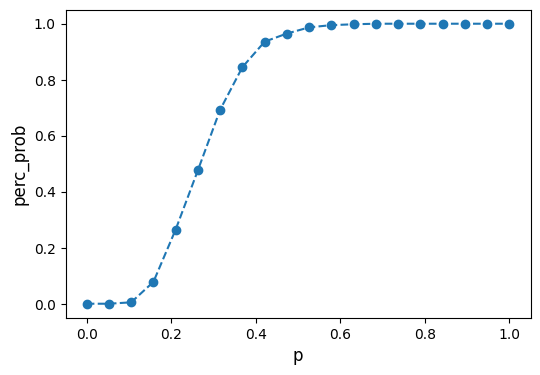

In [161]:
perc_curve(n=10)  # p > 0.6

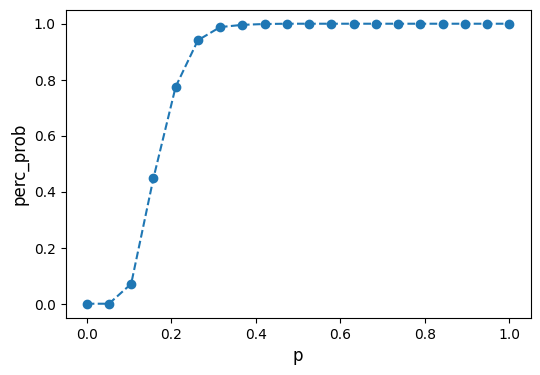

In [162]:
perc_curve(n=20)  # p > 0.4

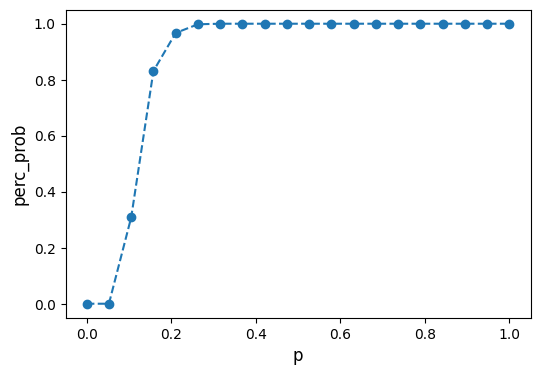

In [163]:
perc_curve(n=30)  # p > 0.3

Чем больше вершин – тем больше потенциальных связей.  
То есть с увеличением числа вершин в графе Эрдеша-Реньи легче получить перколяцию.